In [1]:
# Importing modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.smiles2morganfp import MorganFP
from sklearn.decomposition import TruncatedSVD

In [2]:
# Download all datasets

# from src.utils.download import download_all
# download_all()

In [3]:
# Loading ESOL data
esol_data = pd.read_csv("data/ESOL.csv")[["smiles", "measured log solubility in mols per litre"]]
esol_data = esol_data.rename(columns={"measured log solubility in mols per litre":"target"})

# Loading FreeSolv data
freeSolv_data = pd.read_csv("data/FreeSolv.csv")[["smiles", "expt"]]
freeSolv_data= freeSolv_data.rename(columns={"expt":"target"})

# Loading Lipophilicity data
lipophil_data = pd.read_csv("data/Lipophilicity.csv")[["smiles", "exp"]]
lipophil_data= lipophil_data.rename(columns={"exp":"target"})

# Loading retention time (RT) data
rt_data = pd.read_csv("data/RT.csv")
rt_data= rt_data.rename(columns={"SMILES":"smiles","RTs":"target"})

# Loading B3DB data
b3db_data = pd.read_csv("data/B3DB.tsv", sep="\t")[["SMILES", "logBB"]]
b3db_data = b3db_data.rename(columns={"SMILES":"smiles", "logBB":"target"})

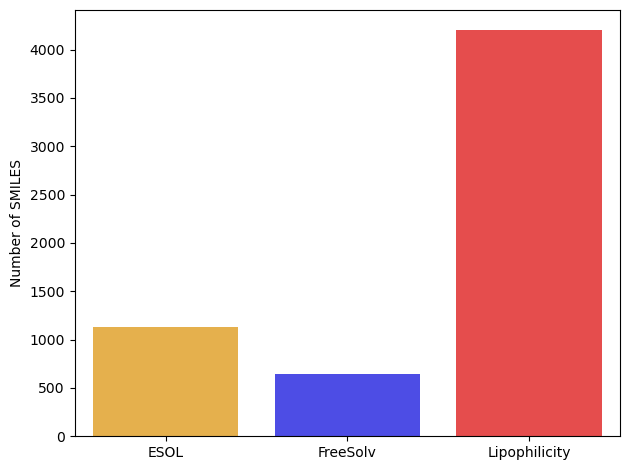

In [4]:
# Plot data
data = {"ESOL":len(esol_data), "FreeSolv":len(freeSolv_data), "Lipophilicity":len(lipophil_data)}
df = pd.DataFrame(list(data.items()), columns=["Dataset", "Count"])
# Plot barplot
plt.figure(dpi=100)
palette = {"ESOL": "orange", "FreeSolv": "blue", "Lipophilicity":"red"}
sns.barplot( x="Dataset", y="Count", data=df, hue="Dataset", palette=palette, alpha=0.8)
plt.ylabel("Number of SMILES")
plt.xlabel("")
plt.tight_layout()
plt.show()

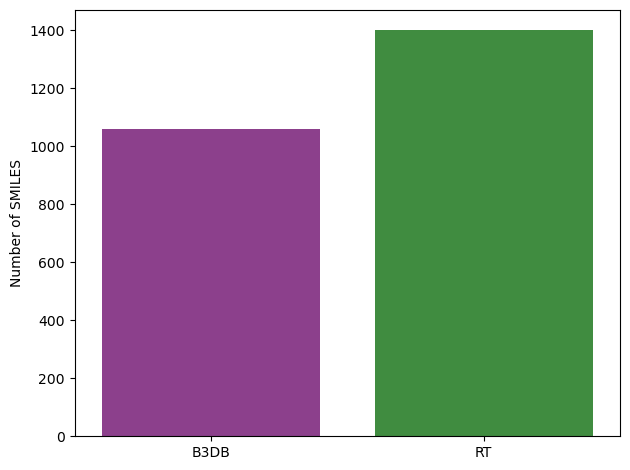

In [5]:
# Plot data
data = {"B3DB":len(b3db_data), "RT":len(rt_data)}
df = pd.DataFrame(list(data.items()), columns=["Dataset", "Count"])
# Plot barplot
plt.figure(dpi=100)
palette = palette = {"B3DB": "purple", "RT": "green"}
sns.barplot( x="Dataset", y="Count", data=df, hue="Dataset", palette=palette, alpha=0.8)
plt.ylabel("Number of SMILES")
plt.xlabel("")
plt.tight_layout()
plt.show()

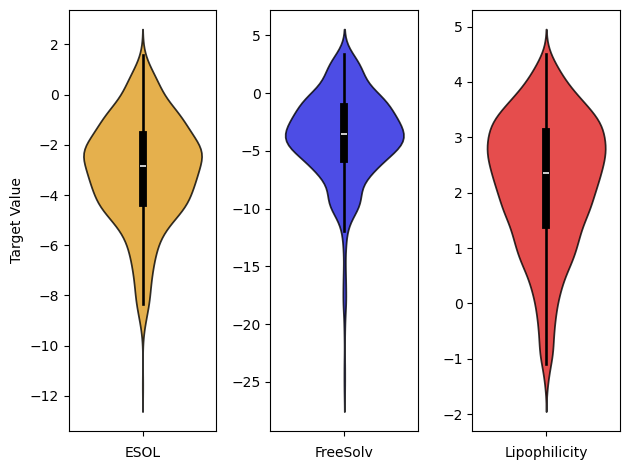

In [6]:
fig, axes = plt.subplots(1, 3, dpi=100)
sns.violinplot(y=esol_data["target"], ax=axes[0], color="orange", linecolor="black", alpha=0.8 )
axes[0].set_title("")
axes[0].set_xlabel("ESOL")
axes[0].set_ylabel("Target Value")
sns.violinplot( y=freeSolv_data["target"], ax=axes[1], color="blue", linecolor="black", alpha=0.8 )
axes[1].set_title("")
axes[1].set_xlabel("FreeSolv")
axes[1].set_ylabel("")
sns.violinplot( y=lipophil_data["target"], ax=axes[2], color="red", linecolor="black", alpha=0.8 )
axes[2].set_title("")
axes[2].set_xlabel("Lipophilicity")
axes[2].set_ylabel("")
plt.tight_layout()
plt.show()

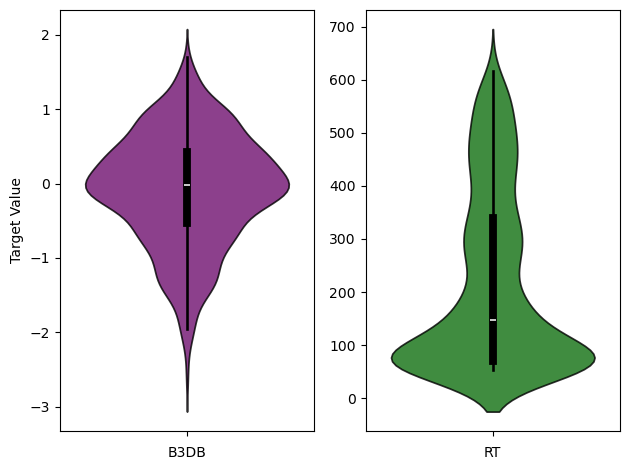

In [7]:
fig, axes = plt.subplots(1, 2, dpi=100)
sns.violinplot(y=b3db_data["target"], ax=axes[0], color="purple", linecolor="black", alpha=0.8 )
axes[0].set_title("")
axes[0].set_xlabel("B3DB")
axes[0].set_ylabel("Target Value")
sns.violinplot( y=rt_data["target"], ax=axes[1], color="green", linecolor="black", alpha=0.8 )
axes[1].set_title("")
axes[1].set_xlabel("RT")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

In [8]:
# Generate ESOL FP
esol_fp = MorganFP(esol_data["smiles"])
esol_fp["Dataset"] = "ESOL"

# Generate FreeSolv FP
freeSolv_fp = MorganFP(freeSolv_data["smiles"])
freeSolv_fp["Dataset"] = "FreeSolv"

# Generate Lipophilicity FP
lipophil_fp = MorganFP(lipophil_data["smiles"])
lipophil_fp["Dataset"] = "Lipophilicity"

# Generate B3DB FP
b3db_fp = MorganFP(b3db_data["smiles"])
b3db_fp["Dataset"] = "B3DB"

# Generate RT FP
rt_fp = MorganFP(rt_data["smiles"])
rt_fp["Dataset"] = "RT"

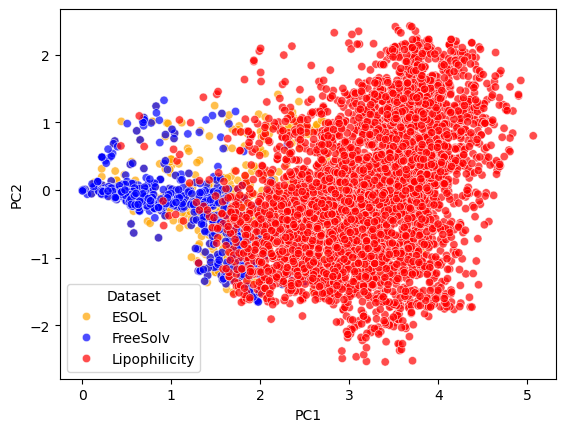

In [9]:
# DF for PCA
temp_df = pd.concat([esol_fp, freeSolv_fp, lipophil_fp])
X = temp_df.drop(["Dataset"], axis=1)

# PCA (TruncatedSVD)
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X.values)

# Plotting 
plot_data = pd.DataFrame(X_svd, columns=[f"PC1", "PC2"])
plot_data["Dataset"] = temp_df["Dataset"].to_numpy()
palette = {"ESOL": "orange", "FreeSolv": "blue", "Lipophilicity":"red"}
sns.scatterplot(x="PC1", y="PC2", hue="Dataset", data=plot_data, alpha=0.7, palette=palette)
plt.show()

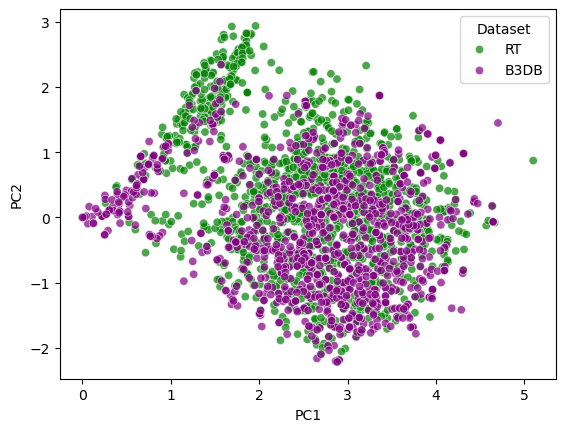

In [10]:
# DF for PCA
temp_df = pd.concat([rt_fp, b3db_fp])
X = temp_df.drop(["Dataset"], axis=1)

# PCA (TruncatedSVD)
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X.values)

# Plotting 
plot_data = pd.DataFrame(X_svd, columns=["PC1", "PC2"])
plot_data["Dataset"] = temp_df["Dataset"].to_numpy()
palette = {"B3DB": "purple", "RT": "green"}
sns.scatterplot(x="PC1", y="PC2", hue="Dataset", data=plot_data, alpha=0.7, palette=palette)
plt.show()

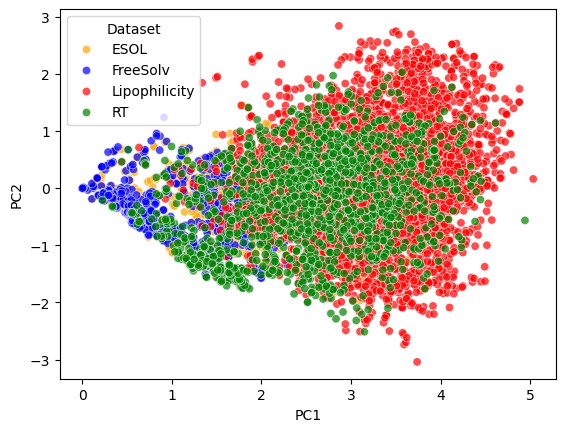

In [11]:
# DF for PCA
temp_df = pd.concat([esol_fp, freeSolv_fp, lipophil_fp, rt_fp])
X = temp_df.drop(["Dataset"], axis=1)

# PCA (TruncatedSVD)
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X.values)

# Plotting 
plot_data = pd.DataFrame(X_svd, columns=[f"PC1", "PC2"])
plot_data["Dataset"] = temp_df["Dataset"].to_numpy()
palette = {"ESOL": "orange", "FreeSolv": "blue", "Lipophilicity":"red", "RT":"green"}
sns.scatterplot(x="PC1", y="PC2", hue="Dataset", data=plot_data, alpha=0.7, palette=palette)
plt.show()

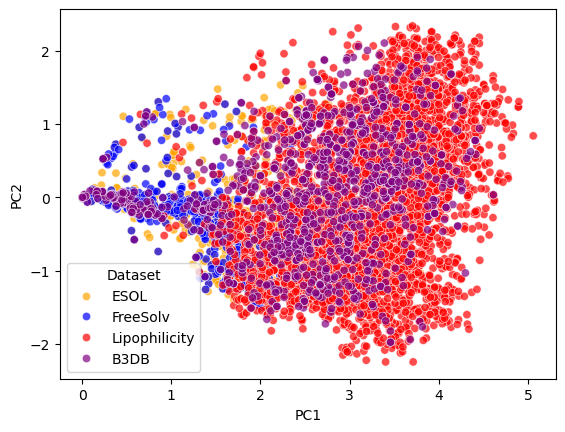

In [12]:
# DF for PCA
temp_df = pd.concat([esol_fp, freeSolv_fp, lipophil_fp, b3db_fp])
X = temp_df.drop(["Dataset"], axis=1)

# PCA (TruncatedSVD)
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X.values)

# Plotting 
plot_data = pd.DataFrame(X_svd, columns=[f"PC1", "PC2"])
plot_data["Dataset"] = temp_df["Dataset"].to_numpy()
palette = {"ESOL": "orange", "FreeSolv": "blue", "Lipophilicity":"red", "B3DB":"purple"}
sns.scatterplot(x="PC1", y="PC2", hue="Dataset", data=plot_data, alpha=0.7, palette=palette)
plt.show()